<div style="background-color:#5A3516; color:#F3EEE6; padding:22px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h1 style="color:#F3EEE6; margin-bottom:0;"><b>Machine Learning II — Customer Segmentation</b></h1>
<h3 style="color:#D8C0B4; margin-top:6px;">Notebook 1 — Preprocessing</h3>
<p style="color:#D8C0B4; font-size:15px; margin-top:14px;">
This notebook applies the preprocessing decisions motivated by the previous data analysis. The goal is to clean the data, engineer customer features, separate extreme observations and export an unscaled dataset ready for clustering.
</p>
</div>

<div style="background-color:#5A3516; color:#F3EEE6; padding:18px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin-top:0;"><b>Index</b></h2>
<p style="color:#D8C0B4;">This notebook starts from the raw file and contains only the transformations required to produce the clustering inputs.</p>
<ol>
  <li><a href="#section-1-imports-and-data-loading">Imports and data loading</a></li>
  <li><a href="#section-2-data-cleaning">Data cleaning</a></li>
  <li><a href="#section-2-1-invalid-future-years">Invalid future years</a></li>
  <li><a href="#section-2-2-negative-values">Negative values</a></li>
  <li><a href="#section-2-3-negative-percentages">Negative percentages</a></li>
  <li><a href="#section-2-4-data-types">Data type fixes</a></li>
  <li><a href="#section-2-5-missing-values-treatment">Missing values treatment</a></li>
  <li><a href="#section-3-aggregation-feature-engineering">Aggregation feature engineering</a></li>
  <li><a href="#section-4-outlier-separation-and-imputation">Outlier separation and imputation</a></li>
  <li><a href="#section-5-transformation-feature-engineering">Transformation feature engineering</a></li>
  <li><a href="#section-6-outlier-diagnostics">Outlier diagnostics</a></li>
  <li><a href="#section-7-multivariate-analysis">Post preprocessing feature checks</a></li>
  <li><a href="#section-8-feature-selection-and-export">Feature selection and final export</a></li>
</ol>
</div>

<a id="section-1-imports-and-data-loading"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>1. Imports and Data Loading</b></h2>
</div>

In [1]:
import warnings

import pandas as pd

warnings.filterwarnings("ignore")

import utils_eda as utils

utils.set_plot_style()
pd.set_option("display.max_columns", None)


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The raw data is loaded again in this notebook so the preprocessing workflow can be executed independently from the exploratory analysis notebook.
</div>

In [2]:
DATA_PATH = "../datasets/customer_info.csv"
ci = pd.read_csv(DATA_PATH)

In [3]:
ci.sort_index(inplace=True)
print("Raw data shape:", ci.shape)
display(ci.head())

Raw data shape: (33038, 25)


,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
0,3,Bsc. Crystal Kitchens,female,02/12/1970 01:36 PM,1.0,1.0,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,177.0,28.0,213.0,552.0,256.0,384.0,189.0,0.631599,2020.0,1.0,38.794428,-9.215739
1,4,Bsc. Glenda Bauman,female,11/13/1975 06:58 PM,1.0,0.0,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,95.0,43.0,15.0,1880.0,333.0,665.0,130.0,0.149890,2013.0,1.0,38.751711,-9.179611
2,5,Msc. Antonio Campbell,male,09/10/1971 10:07 AM,0.0,0.0,NaN,2.0,12407.0,0.0,11.0,555.0,101.0,118.0,1265.0,273.0,507.0,101.0,222.0,81.0,0.069126,2005.0,NaN,38.780678,-9.160656
3,7,John Kelling,male,10/23/1982 11:20 AM,0.0,0.0,2.0,1.0,7493.0,1105.0,18.0,84.0,757.0,1133.0,972.0,1083.0,485.0,1656.0,184.0,92.0,0.253609,2021.0,1.0,38.739548,-9.148679
4,8,Arthur Dematteo,male,08/04/1969 10:22 PM,0.0,0.0,3.0,1.0,9187.0,10841.0,17.0,380.0,592.0,718.0,1068.0,1015.0,297.0,1258.0,441.0,6.0,0.186569,2021.0,1.0,38.733071,-9.188188


<a id="section-2-data-cleaning"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>2. Data Cleaning</b></h2>
</div>


In [4]:
ci_clean = ci.copy()
print("Initial shape:", ci_clean.shape)

Initial shape: (33038, 25)


<a id="section-2-1-invalid-future-years"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>2.1 Detecting Invalid Future Years</b></h2>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

To convert static dates into dynamic behavioral features, we first establish the current temporal baseline.

* **Objective:** Capture the current year using `pd.Timestamp.now().year`.
* **Application:** This value serves as the reference point for calculating:
    * **Customer Age:** Derived from `customer_birthdate`.
    * **Customer Tenure:** Calculated as the difference between the current year and the `year_first_transaction`.
* **Impact:** Transforming years and dates into "Age" and "Years as Customer" provides the clustering algorithm with numerical distances that represent lifecycle stages, which is far more predictive than raw date strings.

</div>

In [5]:
current_year = pd.Timestamp.now().year
print("Current year:", current_year)

Current year: 2026


In [7]:
invalid_years_rows = utils.get_invalid_years(ci_clean)

if not invalid_years_rows.empty:
    print(f"Future years detected: {invalid_years_rows['year_first_transaction'].unique()}")
    display(invalid_years_rows.head())

Future years detected: [2029. 2028. 2027.]


,customer_id,customer_name,customer_gender,customer_birthdate,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,year_first_transaction,loyalty_card_number,latitude,longitude
17,25,Phd. Tom Fisher,male,03/17/2001 10:08 AM,0.0,0.0,NaN,2.0,8829.0,345.0,8.0,NaN,121.0,1657.0,1028.0,758.0,91.0,475.0,44.0,61.0,0.653237,2029.0,1.0,38.707590,-9.161818
28,37,Phd. Alonzo Crossan,male,09/29/2000 07:54 PM,1.0,1.0,0.0,5.0,25539.0,1089.0,7.0,907.0,1681.0,896.0,1153.0,962.0,1205.0,344.0,329.0,330.0,-0.184820,2028.0,1.0,38.729700,-9.196585
66,82,Msc. Heather Howie,female,09/25/2001 01:21 AM,0.0,0.0,0.0,2.0,8073.0,1372.0,8.0,123.0,304.0,1326.0,367.0,259.0,237.0,441.0,171.0,49.0,0.609053,2029.0,1.0,38.756427,-9.162594
92,115,Toni Sultan,female,03/14/1999 10:40 PM,1.0,1.0,2.0,1.0,17941.0,16101.0,23.0,268.0,596.0,1422.0,700.0,839.0,197.0,1409.0,294.0,161.0,0.414479,2027.0,1.0,38.722565,-9.149736
115,141,Bsc. Evelyn Hoffman,female,01/13/2000 07:00 AM,0.0,0.0,0.0,2.0,11257.0,412.0,9.0,1636.0,485.0,103.0,99.0,85.0,1846.0,115.0,14.0,191.0,0.304802,2028.0,1.0,38.754510,-9.183423


In [8]:
ci_clean, future_year_count = utils.set_future_years_to_missing(ci_clean, current_year)

print(f"Future transaction years set to NaN: {future_year_count}")
print(f"Records kept: {len(ci_clean)}")


Future transaction years set to NaN: 991
Records kept: 33038


<a id="section-2-2-negative-values"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>2.2 Detecting Negative Values</b></h2>
</div>


In [9]:
negative_values = ci_clean.select_dtypes(include=['number']).lt(0).any()
negative_values

customer_id                                False
kids_home                                  False
teens_home                                 False
number_complaints                          False
distinct_stores_visited                    False
lifetime_spend_groceries                   False
lifetime_spend_electronics                 False
typical_hour                               False
lifetime_spend_vegetables                  False
lifetime_spend_nonalcohol_drinks           False
lifetime_spend_alcohol_drinks              False
lifetime_spend_meat                        False
lifetime_spend_fish                        False
lifetime_spend_hygiene                     False
lifetime_spend_videogames                  False
lifetime_spend_petfood                     False
lifetime_total_distinct_products           False
percentage_of_products_bought_promotion     True
year_first_transaction                     False
loyalty_card_number                        False
latitude            

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

### Negative Value Analysis

To ensure the logical consistency of our features before modeling, we scan all numerical columns for values below zero.

* **Objective:** Use `.lt(0).any()` to detect logical anomalies across numerical datatypes.
* **Findings:**
    * **`longitude`:** Contains negative values, which is **logically valid** because Lisbon is located west of the Greenwich meridian.
    * **`percentage_of_products_bought_promotion`:** Contains negative values, which is a **logical error** for a percentage metric.
* **Impact:** Identifying these anomalies prevents the inclusion of "placeholder" values (like -1 for missing data) that would otherwise distort the mean and variance of features during the clustering process.

</div>

<a id="section-2-3-negative-percentages"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>2.3 Fixing Negative Percentages</b></h2>
</div>


In [10]:
ci_clean, invalid_promo_count = utils.set_invalid_promotion_to_missing(ci_clean)

print(f"Invalid promotion percentage values: {invalid_promo_count}")
display(ci_clean["percentage_of_products_bought_promotion"].describe())


Invalid promotion percentage values: 1755


count    30953.000000
mean         0.343870
std          0.268770
min          0.000005
25%          0.139284
50%          0.254525
75%          0.491430
max          1.000000
Name: percentage_of_products_bought_promotion, dtype: float64

<a id="section-2-4-data-types"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>2.4 Fixing Data Types</b></h2>
</div>


In [11]:
ci_clean = utils.parse_birthdate(ci_clean)

print("Invalid birthdates after parsing:", ci_clean["customer_birthdate"].isna().sum())


Invalid birthdates after parsing: 165


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

To ensure mathematical operations and time series analyses function correctly, we cast raw object columns into their appropriate structural formats.

* **Objective:** Convert based on strings dates and mixed type numerical strings into usable `datetime64` and `numeric` formats.
* **Key Transformations:**
    * **Temporal Casting:** `customer_birthdate` is parsed using a specific format string (`%m/%d/%Y %I:%M %p`) to enable age calculations.
    * **Integer Enforcement:** Columns like `kids_home` and `number_complaints` are coerced to numeric types. By using `errors='coerce'`, any not numeric noise is safely converted to `NaN`.
* **Impact:** Standardizing types is critical for the "Temporal Baseline" established earlier. For instance, `loyalty_card_number` is revealed as a Boolean style float (1.0 or NaN), which can now be treated as a categorical flag for loyalty membership.

</div>

In [12]:
int_columns = [
    "kids_home",
    "teens_home",
    "number_complaints",
    "distinct_stores_visited",
    "typical_hour",
    "lifetime_total_distinct_products",
    "year_first_transaction",
]

ci_clean = utils.coerce_numeric_columns(ci_clean, int_columns)


In [14]:
ci_clean = utils.apply_cyclic_transformation(ci_clean, "typical_hour", max_val=24)

print(ci_clean[["typical_hour", "typical_hour_sin", "typical_hour_cos"]].head())


   typical_hour  typical_hour_sin  typical_hour_cos
0           NaN               NaN               NaN
1           NaN               NaN               NaN
2          11.0          0.258819     -9.659258e-01
3          18.0         -1.000000     -1.836970e-16
4          17.0         -0.965926     -2.588190e-01


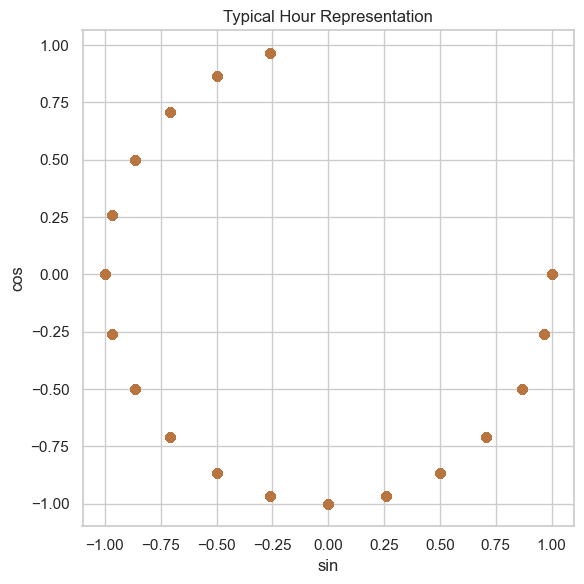

In [15]:
utils.plot_cyclic_hour(ci_clean)


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">


Time of day data is inherently cyclical (23:00 is closer to 01:00 than it is to 13:00). To ensure our model understands this relationship, we map the linear `typical_hour` onto a 2D coordinate system.

* **Objective:** Transform the 24-hour cycle into Sine and Cosine components using a `cyclic_transformation`.
* **The Logic:** Raw numerical hours (0-23) create a "jump" or distance gap between the end of one day and the start of the next.
    * By mapping hours to a circle, **Hour 23** and **Hour 0** become spatially adjacent, preserving the temporal continuity of human behavior.
* **Impact:** The resulting scatter plot forms a perfect circle, confirming that the "Typical Hour" has been successfully projected into a format that allows clustering algorithms to calculate meaningful distances between different times of day.

</div>

<a id="section-2-5-missing-values-treatment"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>2.5 Missing Values Treatment</b></h2>
</div>


In [18]:
print("Missing values BEFORE imputation:")
display(ci_clean.isna().sum())

Missing values BEFORE imputation:


customer_id                                    0
customer_name                                  0
customer_gender                                0
customer_birthdate                           165
kids_home                                    330
teens_home                                   330
number_complaints                            661
distinct_stores_visited                      330
lifetime_spend_groceries                       0
lifetime_spend_electronics                   661
typical_hour                                 661
lifetime_spend_vegetables                    661
lifetime_spend_nonalcohol_drinks               0
lifetime_spend_alcohol_drinks                330
lifetime_spend_meat                          661
lifetime_spend_fish                          991
lifetime_spend_hygiene                       330
lifetime_spend_videogames                    661
lifetime_spend_petfood                       661
lifetime_total_distinct_products               0
percentage_of_produc

In [19]:
ci_clean = utils.fill_zero_count_columns(
    ci_clean,
    columns=["kids_home", "teens_home", "number_complaints"],
)


In [20]:
ci_clean = utils.encode_loyalty_flag(ci_clean)

print(ci_clean["customer_loyalty_flag"].value_counts())


customer_loyalty_flag
1    19932
0    13106
Name: count, dtype: int64


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">


Handling null values is a critical step to prevent model bias and calculation errors. In this section, we address the sparsity discovered in several key features.

* **Objective:** Quantify missing data using `.isna().sum()` and apply specific to the domain imputation rules.
* **Treatment Logic:**
    * **Zero Imputation:** For count variables such as `kids_home`, `teens_home`, and `number_complaints`, missing values are treated as **0**, assuming the absence of a record implies a zero count.
    * **Flag Transformation:** The `loyalty_card_number` column is renamed to `customer_loyalty_flag` and converted into a binary indicator ($1$ for members, $0$ for customers without membership).
* **Impact:** By resolving the 13,106 missing loyalty entries and filling behavioral counts, we ensure the dataset is structurally complete. This prepares the "sparse" features for statistical analysis without losing significant row volume.

</div>

In [21]:
print(f"Shape before removing semi-constants: {ci_clean.shape}")

protected_cols = [
    'customer_id',
    'loyalty_card_number',
    'customer_loyalty_flag',
    'is_male',
    'education_level'
]

ci_clean = utils.remove_semi_constant_features(
    ci_clean,
    threshold=0.99,
    exclude_cols=protected_cols
)

print(f"Shape after removing semi-constants: {ci_clean.shape}")


Shape before removing semi-constants: (33038, 27)
Semi-constant columns removed (>=99% identical): []
Shape after removing semi-constants: (33038, 27)


<a id="section-3-aggregation-feature-engineering"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>3. Aggregation Feature Engineering</b></h2>
</div>


In [22]:
ci_clean, age_summary = utils.add_customer_age(ci_clean)

print(f"Minimum Age: {age_summary['min_age']}")
print(f"Maximum Age: {age_summary['max_age']}")
print(f"Invalid or suspicious ages: {age_summary['invalid_count']}")


Minimum Age: 24.0
Maximum Age: 86.0
Invalid or suspicious ages: 0


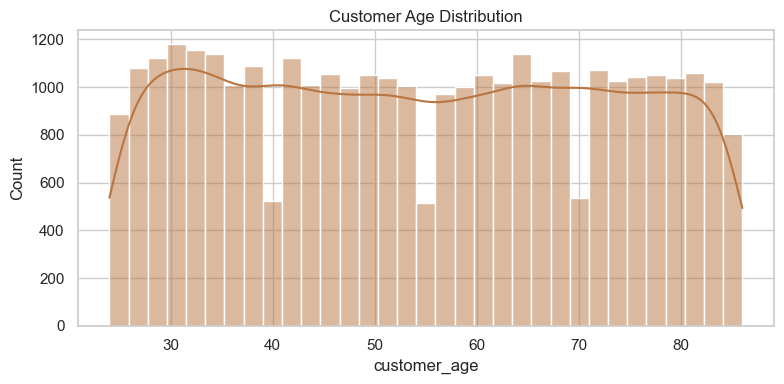

In [23]:
utils.plot_age_distribution(ci_clean)


In [24]:
education_df = ci_clean.apply(utils.get_education_info, axis=1)

ci_clean["education_level"] = education_df[0].astype(int)
ci_clean["clean_customer_name"] = education_df[1]

print("Distribution of identified education levels:")
print(ci_clean["education_level"].value_counts().sort_index())

display(ci_clean[["customer_name", "clean_customer_name", "education_level"]].head())


Distribution of identified education levels:
education_level
12    17731
15     5154
17     5057
22     5096
Name: count, dtype: int64


,customer_name,clean_customer_name,education_level
0,Bsc. Crystal Kitchens,Crystal Kitchens,15
1,Bsc. Glenda Bauman,Glenda Bauman,15
2,Msc. Antonio Campbell,Antonio Campbell,17
3,John Kelling,John Kelling,12
4,Arthur Dematteo,Arthur Dematteo,12


In [25]:
ci_clean = utils.encode_gender(ci_clean)
display(ci_clean[["customer_gender", "is_male"]].head())


,customer_gender,is_male
0,female,0
1,female,0
2,male,1
3,male,1
4,male,1


In [26]:
ci_clean.drop(columns=['customer_gender'], inplace=True)

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

This step turns raw demographic information into variables that can be used in modelling.

* <b>Education level:</b> extracted safely from <code>customer_name</code> using regex, so customer names are not accidentally corrupted.
* <b>Gender:</b> encoded as a binary flag, making it compatible with based on distance models.
* <b>Customer age:</b> calculated from birthdate and checked for unrealistic values before imputation.

The result is a cleaner dataset with less text noise and more useful numerical signal.
* <b>Note on the education scale:</b> the year values (12 / 15 / 17 / 22) are an assumption about typical degree duration, and customers with no academic prefix are coded as 12 — i.e. “unknown” is grouped with high school. This is a documented assumption, not a measured fact.

</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
After creating the main demographic and loyalty features, we briefly inspect their distributions. These variables are useful for profiling and interpretation, even when some of them are not used directly in the clustering distance.
</div>

,column,value,count,percentage_%
0,is_male,0.0,16577,50.18
1,is_male,1.0,16461,49.82
2,customer_loyalty_flag,1.0,19932,60.33
3,customer_loyalty_flag,0.0,13106,39.67
4,education_level,12.0,17731,53.67
5,education_level,15.0,5154,15.60
6,education_level,22.0,5096,15.42
7,education_level,17.0,5057,15.31
8,kids_home,1.0,16012,48.47
9,kids_home,0.0,9533,28.85


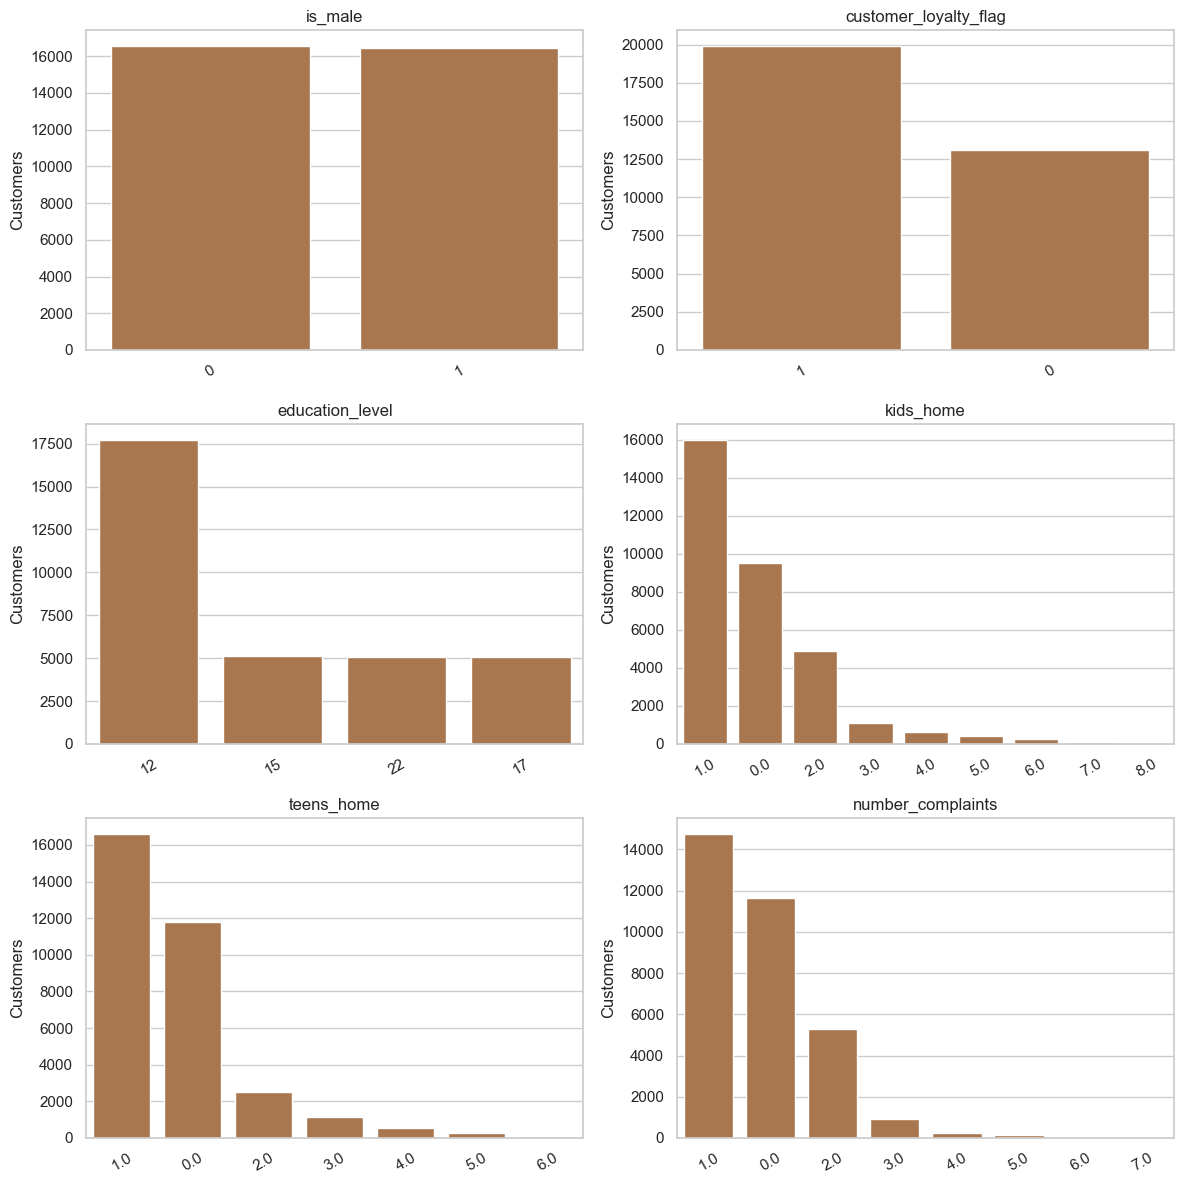

In [27]:
categorical_review_cols = [
    "is_male",
    "customer_loyalty_flag",
    "education_level",
    "kids_home",
    "teens_home",
    "number_complaints",
]

categorical_review = utils.categorical_summary(ci_clean, categorical_review_cols)
display(categorical_review)

utils.plot_categorical_summary(ci_clean, categorical_review_cols)

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The categorical and count distributions help verify that the engineered features are reasonable before export. Gender is kept as a binary flag, loyalty is represented separately from the raw card number, and education is treated as an approximate numeric proxy derived from name prefixes.
</div>

<a id="section-4-outlier-separation-and-imputation"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>4. Consensus Outlier Separation and KNN Imputation</b></h2>
</div>


In [30]:
ci_clean.drop(columns=["customer_name", "clean_customer_name"], inplace=True, errors="ignore")


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

Before imputing missing values, the most atypical customers are separated into an outlier dataset. The rule is conservative: a customer is only kept aside when it is simultaneously flagged by three methods.

* <b>IQR:</b> detects unusually high or low values in numerical variables.
* <b>DBSCAN:</b> identifies observations located in sparse areas of the feature space.
* <b>SOM:</b> highlights customers with high reconstruction error in a SOM map.

The thresholds are kept below the 5% reference limit. These customers are not discarded; they are exported separately and later assigned to the closest final segment in the clustering notebook.

</div>


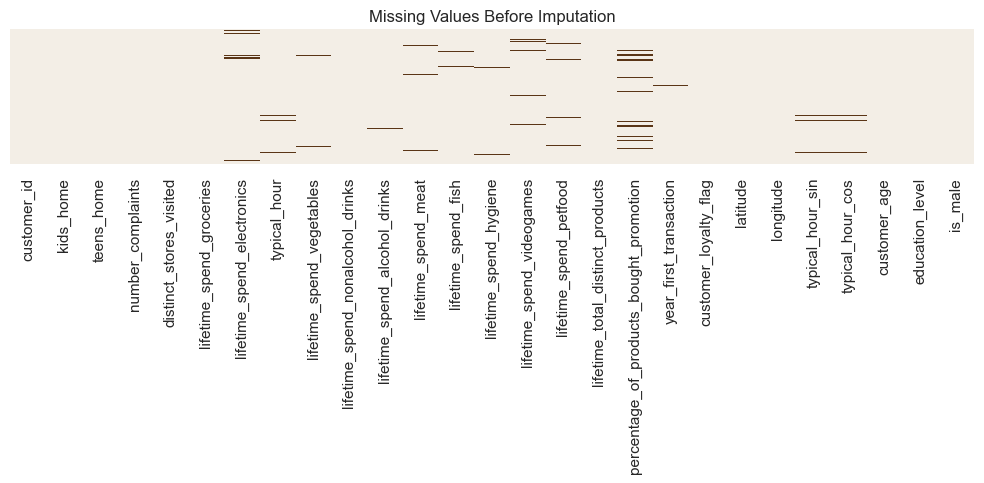

                                         Missing Count  Percentage (%)
percentage_of_products_bought_promotion           2085            6.31
lifetime_spend_fish                                991            3.00
year_first_transaction                             991            3.00
lifetime_spend_electronics                         661            2.00
typical_hour                                       661            2.00
lifetime_spend_vegetables                          661            2.00
lifetime_spend_meat                                661            2.00
lifetime_spend_videogames                          661            2.00
lifetime_spend_petfood                             661            2.00
typical_hour_sin                                   661            2.00
typical_hour_cos                                   661            2.00
distinct_stores_visited                            330            1.00
lifetime_spend_alcohol_drinks                      330            1.00
lifeti

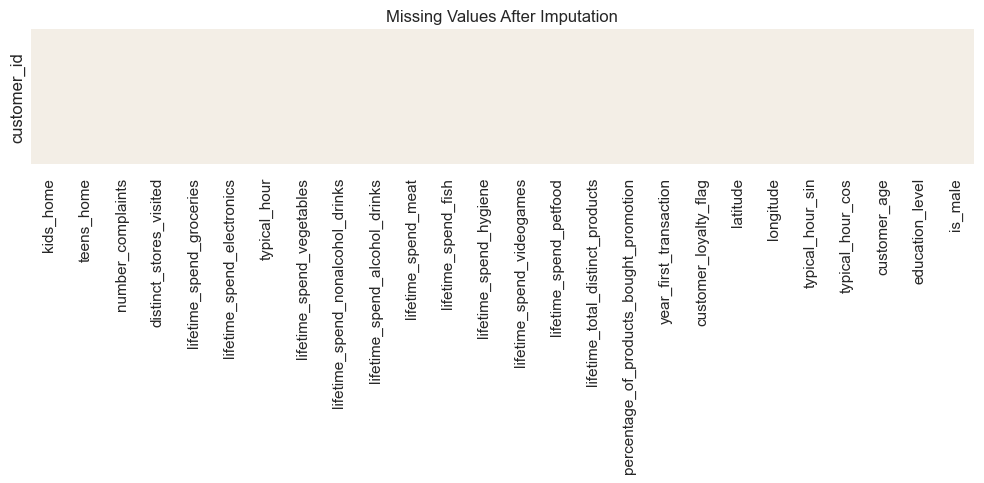

In [31]:
ci_clean, outlier_dataset, outlier_summary = utils.separate_outliers_and_impute_regular(
    ci_clean,
    index_col="customer_id",
    outlier_method="consensus",
    iqr_k=2.0,
    dbscan_eps=1.0,
    som_percentile=95,
    max_remove_pct=5.0,
)


In [32]:
to_int = [
    "kids_home",
    "teens_home",
    "number_complaints",
    "distinct_stores_visited",
    "lifetime_total_distinct_products",
    "year_first_transaction",
    "customer_loyalty_flag",
    "education_level",
    "is_male",
]

ci_clean = utils.cast_nullable_int(ci_clean, to_int)


In [33]:
ci_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32056 entries, 3 to 40000
Data columns (total 26 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   kids_home                                32056 non-null  Int64  
 1   teens_home                               32056 non-null  Int64  
 2   number_complaints                        32056 non-null  Int64  
 3   distinct_stores_visited                  32056 non-null  Int64  
 4   lifetime_spend_groceries                 32056 non-null  float64
 5   lifetime_spend_electronics               32056 non-null  float64
 6   typical_hour                             32056 non-null  float64
 7   lifetime_spend_vegetables                32056 non-null  float64
 8   lifetime_spend_nonalcohol_drinks         32056 non-null  float64
 9   lifetime_spend_alcohol_drinks            32056 non-null  float64
 10  lifetime_spend_meat                      32056 non-

<a id="section-5-transformation-feature-engineering"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>5. Transformation Feature Engineering</b></h2>
</div>


In [34]:
ci_clean = utils.engineer_clustering_features(
    ci_clean,
    current_year,
    keep_absolute_spend=True
)

print("Columns after feature engineering:")
display(ci_clean.columns.tolist())

absolute_spend_cols = [c for c in ci_clean.columns if c.startswith("lifetime_spend_")]

print(f"Absolute lifetime spend columns kept: {len(absolute_spend_cols)}")
for c in absolute_spend_cols:
    print("-", c)


Columns after feature engineering:


['kids_home',
 'teens_home',
 'number_complaints',
 'distinct_stores_visited',
 'lifetime_spend_groceries',
 'lifetime_spend_electronics',
 'lifetime_spend_vegetables',
 'lifetime_spend_nonalcohol_drinks',
 'lifetime_spend_alcohol_drinks',
 'lifetime_spend_meat',
 'lifetime_spend_fish',
 'lifetime_spend_hygiene',
 'lifetime_spend_videogames',
 'lifetime_spend_petfood',
 'lifetime_total_distinct_products',
 'percentage_of_products_bought_promotion',
 'customer_loyalty_flag',
 'latitude',
 'longitude',
 'typical_hour_sin',
 'typical_hour_cos',
 'customer_age',
 'education_level',
 'is_male',
 'tenure',
 'total_children',
 'lifetime_spend_technology',
 'log_total_spend']

Absolute lifetime spend columns kept: 11
- lifetime_spend_groceries
- lifetime_spend_electronics
- lifetime_spend_vegetables
- lifetime_spend_nonalcohol_drinks
- lifetime_spend_alcohol_drinks
- lifetime_spend_meat
- lifetime_spend_fish
- lifetime_spend_hygiene
- lifetime_spend_videogames
- lifetime_spend_petfood
- lifetime_spend_technology


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

## Spending-share features

Absolute lifetime spend tells us *how much* each customer spent per category,
but a customer who spent €500 on vegetables out of a total budget of €5 000 has
a very different preference profile from one who spent the same €500 out of €600.
Share features capture this preference dimension by expressing each category as a
**fraction of total spend**, removing the confound of overall spending power.

Each new column is named `<category>_share` (e.g. `vegetables_share`) and is
defined as:

```
category_share = lifetime_spend_<category> / (total_spend + ε)
```

where `ε` is a tiny constant that prevents division-by-zero for customers with
no recorded spend.  Share features always sum to (approximately) 1 across
categories, so they are scale-invariant and work well with any scaler.
The original `lifetime_spend_*` columns are preserved alongside them.

</div>


In [35]:
spend_cols_all = [c for c in ci_clean.columns if c.startswith('lifetime_spend_')]
ci_clean['total_spend'] = ci_clean[spend_cols_all].sum(axis=1)

# Sanity check: flag customers with zero total spend (shares would be meaningless)
zero_spend = (ci_clean['total_spend'] == 0).sum()
if zero_spend:
    print(f'  Warning: {zero_spend} customers have total_spend = 0 — shares will be 0 for all categories.')
else:
    print('  All customers have positive total spend — share computation is safe.')

# Create spending-share features (groceries excluded — it dominates and obscures variation)
ci_clean = utils.add_spend_share_features(
    ci_clean,
    spend_prefix='lifetime_spend_',
    total_col='total_spend',
    exclude_categories=['groceries'],
)

share_cols = [c for c in ci_clean.columns if c.endswith('_share')]
print(f'Spending-share columns ({len(share_cols)}):')
for c in share_cols:
    print('-', c)

display(ci_clean[share_cols].describe().T.round(4))


Spending-share features added: 10  (excluded: ['groceries'])
Spending-share columns (10):
- electronics_share
- vegetables_share
- nonalcohol_drinks_share
- alcohol_drinks_share
- meat_share
- fish_share
- hygiene_share
- videogames_share
- petfood_share
- technology_share


,count,mean,std,min,25%,50%,75%,max
electronics_share,32056.0,0.0913,0.0823,0.0000,0.0310,0.0679,0.1226,0.4275
vegetables_share,32056.0,0.0386,0.0456,0.0000,0.0085,0.0200,0.0540,0.5135
nonalcohol_drinks_share,32056.0,0.0199,0.0133,0.0000,0.0111,0.0166,0.0250,0.1937
alcohol_drinks_share,32056.0,0.0252,0.0210,0.0000,0.0104,0.0199,0.0346,0.3778
meat_share,32056.0,0.0315,0.0267,0.0000,0.0141,0.0272,0.0419,0.4363
fish_share,32056.0,0.0244,0.0204,0.0000,0.0088,0.0210,0.0338,0.2622
hygiene_share,32056.0,0.0393,0.0373,0.0000,0.0153,0.0287,0.0492,0.4154
videogames_share,32056.0,0.0145,0.0163,0.0000,0.0055,0.0092,0.0159,0.1864
petfood_share,32056.0,0.0165,0.0127,0.0000,0.0081,0.0135,0.0213,0.2047
technology_share,32056.0,0.1058,0.0905,0.0004,0.0413,0.0794,0.1358,0.4611


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

Feature engineering is applied after data cleaning and imputation. The exported dataset keeps both the absolute `lifetime_spend_*` columns and the new `*_share` columns, because the final feature-set decision is made in the clustering notebook — where both can be evaluated independently.

</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

## Absolute spend feature set

This feature set keeps absolute lifetime spending variables as the main spending block, together with engineered demographic and behavioural features such as age, cyclic hour, education years, tenure, loyalty flag and gender.

A separate absolute spend view is created to inspect the final feature structure before export.

</div>


In [36]:
ci_absolute_spend = utils.make_absolute_spend_view(ci_clean)

print("Absolute-spend style dataset shape:", ci_absolute_spend.shape)
print("Absolute-spend style columns:")
for col in ci_absolute_spend.columns:
    print("-", col)


Absolute-spend style dataset shape: (32056, 26)
Absolute-spend style columns:
- kids_home
- teens_home
- number_complaints
- distinct_stores_visited
- lifetime_spend_groceries
- lifetime_spend_electronics
- lifetime_spend_vegetables
- lifetime_spend_nonalcohol_drinks
- lifetime_spend_alcohol_drinks
- lifetime_spend_meat
- lifetime_spend_fish
- lifetime_spend_hygiene
- lifetime_spend_videogames
- lifetime_spend_petfood
- lifetime_spend_technology
- lifetime_total_distinct_products
- percentage_of_products_bought_promotion
- latitude
- longitude
- age
- hour_sin
- hour_cos
- years_education
- years_since_first_transaction
- has_loyalty_card
- customer_gender


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

The exported dataset keeps **absolute lifetime spending variables** alongside the new spending-share features. Scaling and the final feature selection are deferred to the clustering notebook so that different strategies can be compared on the same unscaled inputs.

</div>


<a id="section-6-outlier-diagnostics"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>6. Outlier Diagnostics</b></h2>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

The plots below are used as a final visual check of the main skewed variables after preprocessing. At this point, the extreme subset has already been separated, so these diagnostics help confirm whether the regular customer base is more stable before the clustering stage.

</div>


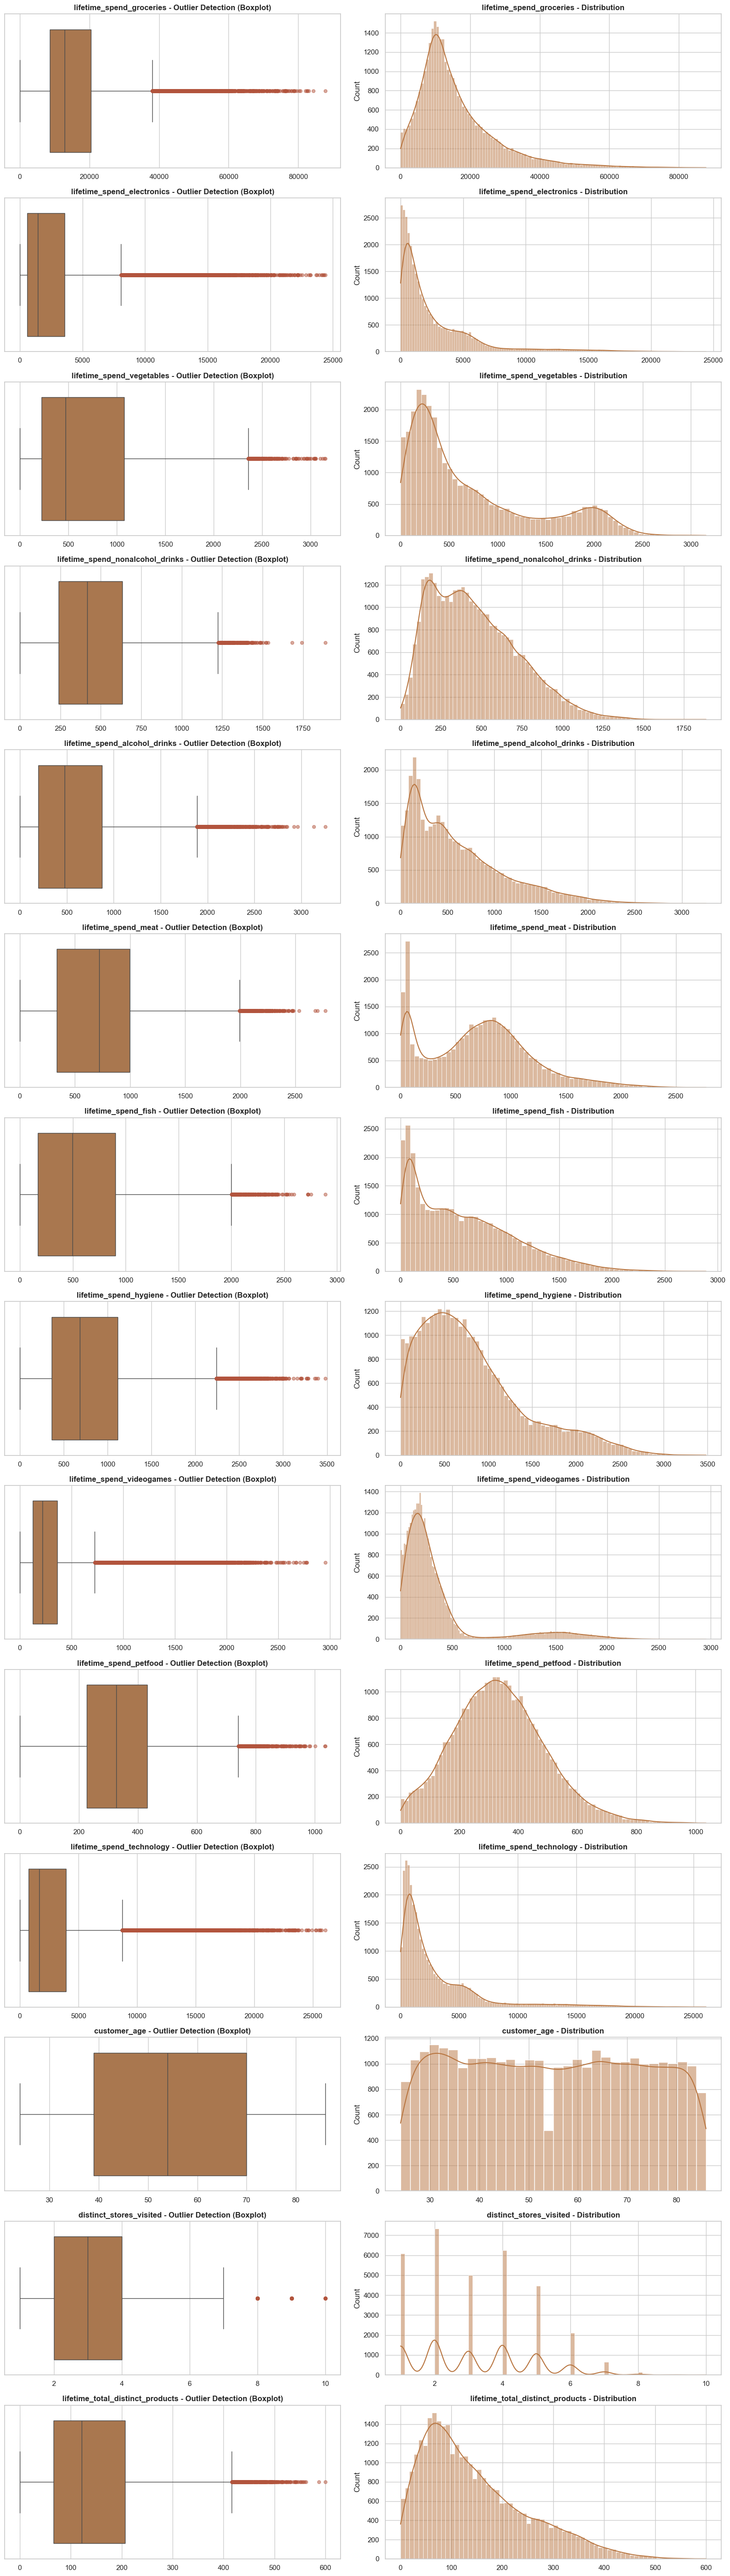

In [38]:
spend_cols = [col for col in ci_clean.columns if col.startswith("lifetime_spend_")]
other_numeric = [
    "customer_age",
    "distinct_stores_visited",
    "lifetime_total_distinct_products",
]
cols_to_visualize = [col for col in spend_cols + other_numeric if col in ci_clean.columns]

utils.plot_outlier_diagnostics(ci_clean, cols_to_visualize)


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

Some high values remain visible in the boxplots after preprocessing — this is expected because lifetime spending is naturally right-skewed. The goal was not to remove every univariate extreme, but to keep valid high-spending customers while separating only the most atypical multivariate cases. After the conservative consensus separation, the regular customer base retains natural variation, which reduces the risk of a small number of outliers dominating the clustering distances.

</div>


<a id="section-7-multivariate-analysis"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>7. Multivariate Analysis: Feature Correlation</b></h2>
</div>


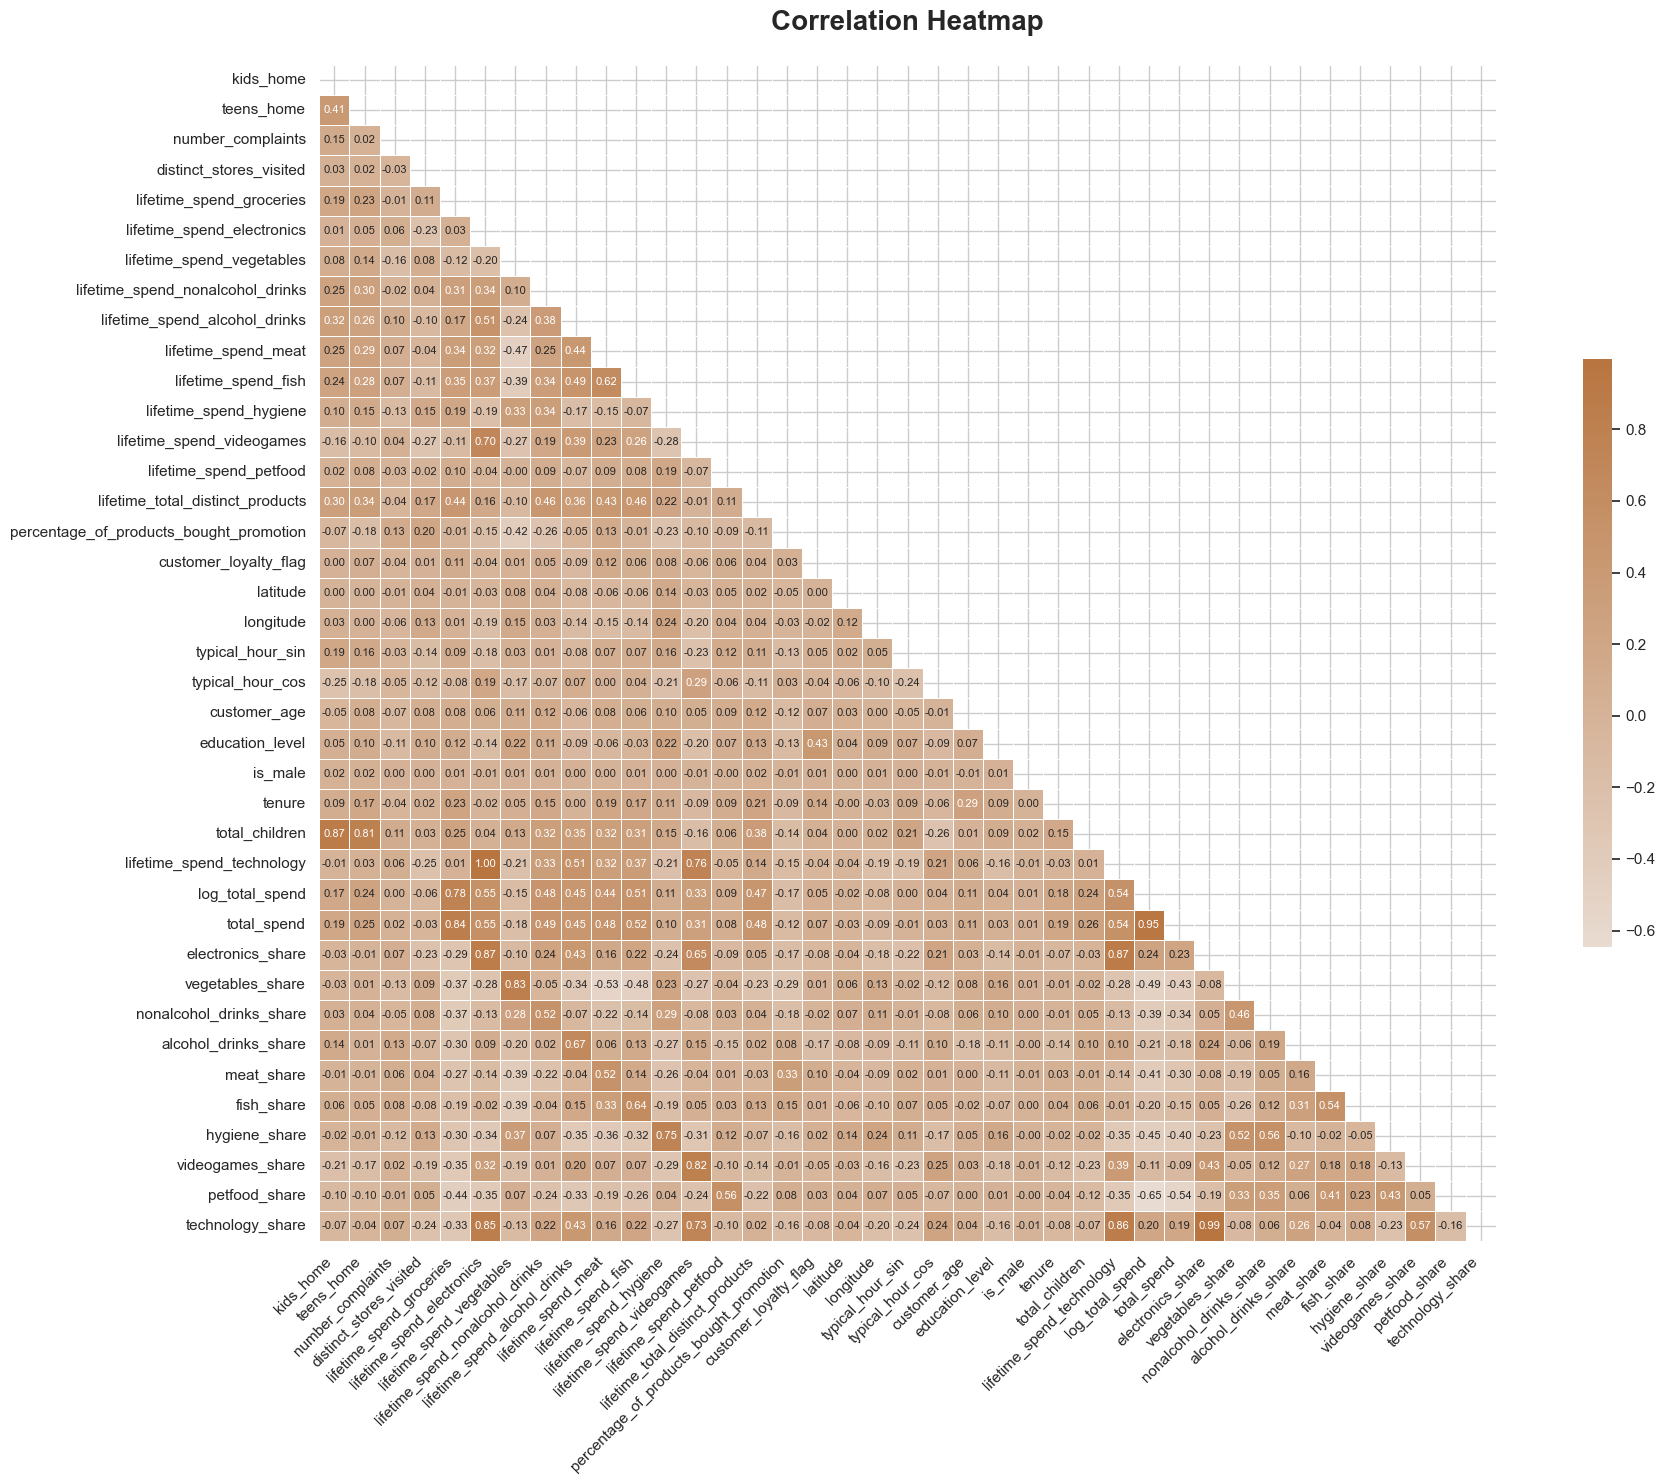

In [39]:
cols_to_corr = utils.correlation_columns(
    ci_clean,
    exclude_cols=["loyalty_card_number"],
)

utils.cor_heatmap(ci_clean[cols_to_corr].corr())


In [40]:
high_corrs = utils.get_high_correlations(ci_clean, threshold=0.7)

display(high_corrs)

,Variable 1,Variable 2,Correlation
4,lifetime_spend_technology,lifetime_spend_electronics,0.996290
15,technology_share,electronics_share,0.986765
14,total_spend,log_total_spend,0.948883
0,total_children,kids_home,0.869776
12,electronics_share,lifetime_spend_technology,0.869315
5,electronics_share,lifetime_spend_electronics,0.867809
13,technology_share,lifetime_spend_technology,0.861380
6,technology_share,lifetime_spend_electronics,0.847459
3,total_spend,lifetime_spend_groceries,0.840727
7,vegetables_share,lifetime_spend_vegetables,0.834314


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

At this stage, we check how strongly numerical variables are related to one another. Highly redundant features can distort based on distance clustering by giving the same information more than one weight.

In the final exported dataset, `year_first_transaction` is replaced by `tenure`, and `typical_hour` is replaced by its cyclic sine/cosine representation. The household variables are reviewed later in the clustering notebook, where only one family representation is used in the distance calculation.

</div>


<a id="section-8-feature-selection-and-export"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>8. Feature Selection and Final Export</b></h2>
</div>


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

## Final clustering dataset

This step prepares the dataset that will be used in the clustering notebook.

The exported dataset is intentionally **unscaled**. It includes absolute lifetime spend features and engineered behavioural variables. Scaling is not applied here because the scaler is part of the clustering model design and must be fitted consistently inside the clustering notebook.

This allows us to compare alternatives such as MinMaxScaler, RobustScaler and StandardScaler before deciding the final KMeans pipeline.

</div>

In [42]:
final_feature_check = pd.DataFrame([
    {
        "raw_feature": "year_first_transaction",
        "replacement": "tenure",
        "status": "removed from final export",
        "reason": "tenure is the customer-lifecycle variable used downstream",
    },
    {
        "raw_feature": "typical_hour",
        "replacement": "typical_hour_sin + typical_hour_cos",
        "status": "removed from final export",
        "reason": "the cyclic representation preserves time-of-day distance",
    },
])

display(final_feature_check)

high_corrs = utils.get_high_correlations(ci_clean, threshold=0.8)
display(high_corrs)

absolute_spend_cols = [c for c in ci_clean.columns if c.startswith("lifetime_spend_")]
print("Absolute spend features kept for clustering:")
for col in absolute_spend_cols:
    print("-", col)

print()
print("Final columns exported:")
print(list(ci_clean.columns))


,raw_feature,replacement,status,reason
0,year_first_transaction,tenure,removed from final export,tenure is the customer-lifecycle variable used...
1,typical_hour,typical_hour_sin + typical_hour_cos,removed from final export,the cyclic representation preserves time-of-da...


,Variable 1,Variable 2,Correlation
3,lifetime_spend_technology,lifetime_spend_electronics,0.996290
11,technology_share,electronics_share,0.986765
10,total_spend,log_total_spend,0.948883
0,total_children,kids_home,0.869776
8,electronics_share,lifetime_spend_technology,0.869315
4,electronics_share,lifetime_spend_electronics,0.867809
9,technology_share,lifetime_spend_technology,0.861380
5,technology_share,lifetime_spend_electronics,0.847459
2,total_spend,lifetime_spend_groceries,0.840727
6,vegetables_share,lifetime_spend_vegetables,0.834314


Absolute spend features kept for clustering:
- lifetime_spend_groceries
- lifetime_spend_electronics
- lifetime_spend_vegetables
- lifetime_spend_nonalcohol_drinks
- lifetime_spend_alcohol_drinks
- lifetime_spend_meat
- lifetime_spend_fish
- lifetime_spend_hygiene
- lifetime_spend_videogames
- lifetime_spend_petfood
- lifetime_spend_technology

Final columns exported:
['kids_home', 'teens_home', 'number_complaints', 'distinct_stores_visited', 'lifetime_spend_groceries', 'lifetime_spend_electronics', 'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene', 'lifetime_spend_videogames', 'lifetime_spend_petfood', 'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion', 'customer_loyalty_flag', 'latitude', 'longitude', 'typical_hour_sin', 'typical_hour_cos', 'customer_age', 'education_level', 'is_male', 'tenure', 'total_children', 'lifetime_spend_technology'

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

## Export final files

The final export stores the prepared datasets used in the modelling stage. Keeping the export step separate makes the transition from preprocessing to clustering clear and reproducible.

</div>

In [43]:
if "outlier_dataset" in locals():
    outlier_dataset = utils.align_outlier_features(
        outlier_dataset,
        reference_df=ci_clean,
        current_year=current_year,
    )


'total_spend' computed from 11 spend columns.
Spending-share features added: 10  (excluded: ['groceries'])
Outlier columns match regular columns: True
Outlier dataset shape: (982, 39)


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

The outlier dataset is aligned with the regular dataset before export, so both files contain the same engineered variables and can be used consistently in the clustering stage.

</div>


In [44]:
utils.export_preprocessing_outputs(
    regular_df=ci_clean,
    outlier_df=outlier_dataset if "outlier_dataset" in locals() else None,
    output_dir="../datasets",
)


Regular dataset exported UNSCALED: (32056, 39)
Outlier dataset exported UNSCALED: (982, 39)
Absolute lifetime spend columns exported: 11
['lifetime_spend_groceries', 'lifetime_spend_electronics', 'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene', 'lifetime_spend_videogames', 'lifetime_spend_petfood', 'lifetime_spend_technology']
All exported columns:
['kids_home', 'teens_home', 'number_complaints', 'distinct_stores_visited', 'lifetime_spend_groceries', 'lifetime_spend_electronics', 'lifetime_spend_vegetables', 'lifetime_spend_nonalcohol_drinks', 'lifetime_spend_alcohol_drinks', 'lifetime_spend_meat', 'lifetime_spend_fish', 'lifetime_spend_hygiene', 'lifetime_spend_videogames', 'lifetime_spend_petfood', 'lifetime_total_distinct_products', 'percentage_of_products_bought_promotion', 'customer_loyalty_flag', 'latitude', 'longitude', 'typical_hour_sin', 'typical_hour_cos', 

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
The final summary checks that preprocessing preserved the customer base, exported the expected files and produced a complete unscaled dataset for the clustering notebook.
</div>

In [45]:
exported_files = ["info_clustering_unscaled.csv"]
if "outlier_dataset" in locals():
    exported_files.append("outlier_dataset.csv")

preprocessing_summary = utils.preprocessing_summary_table(
    raw_df=ci,
    regular_df=ci_clean,
    outlier_df=outlier_dataset if "outlier_dataset" in locals() else None,
    exported_files=exported_files,
)

display(preprocessing_summary)
# Share features are part of the exported dataset
share_feature_count = len([c for c in ci_clean.columns if c.endswith('_share')])
print(f'Spending-share features exported: {share_feature_count}')


,item,value
0,Initial rows,33038
1,Regular rows exported,32056
2,Outlier rows kept aside,982
3,Total rows preserved,33038
4,Final exported features,39
5,Missing values in regular export,0
6,Absolute spend features,11
7,Exported files,"info_clustering_unscaled.csv, outlier_dataset.csv"


<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">

The main unscaled clustering dataset is exported as <code>info_clustering_unscaled.csv</code>. The separated extreme customer subset is also exported as <code>outlier_dataset.csv</code>.

Both exports preserve the DataFrame index, which is important because <code>customer_id</code> was moved to the index to protect it from KNN imputation and scaling.

</div>


<a id="section-9-iqr-capping-alternative"></a>
<div style="background-color:#5A3516; color:#F3EEE6; padding:20px; border-radius:10px; border-left:8px solid #A8B7BA;">
<h2 style="color:#F3EEE6; margin:0;"><b>9. Alternative Preprocessing — IQR Capping</b></h2>
<p style="color:#D8C0B4; margin:6px 0 0 0;">This section produces a second clustering input using IQR capping instead of outlier separation. All customers are kept in a single dataset; extreme values are clipped to <code>Q3 + iqr_k × IQR</code> for spend columns and to symmetric fences for other numeric variables. The capping is applied here, on the full dataset, <b>before any split</b>, so that the IQR bounds reflect the complete customer population.</p>
</div>

<div style="background-color:#7E6A43; color:#F3EEE6; padding:15px; border-radius:10px;">
<b>Why here and not in the clustering notebook.</b><br><br>
IQR capping must be computed on the full customer population. If capping were applied after removing outliers, the fences would be calculated on the already-cleaned dataset, producing tighter bounds that could clip legitimate variation in the regular customer group. Computing capping here, before any split, guarantees that the fence values represent the real population distribution.<br><br>
The two exported files represent two alternative strategies for the same problem:<br>
— <code>info_clustering_unscaled.csv</code>: outlier separation + reattachment via nearest centroid.<br>
— <code>info_clustering_capped.csv</code>: IQR capping, all customers in a single dataset.
</div>

In [46]:
IQR_K_CAPPING = 1.5 

ci_full = pd.concat([ci_clean, outlier_dataset], axis=0) if 'outlier_dataset' in locals() else ci_clean.copy()
print(f'Full dataset shape (regular + outliers): {ci_full.shape}')

spend_and_numeric = [c for c in ci_full.select_dtypes(include='number').columns
                     if c not in ['is_male', 'customer_loyalty_flag', 'education_level',
                                   'typical_hour_sin', 'typical_hour_cos']]

ci_capped = utils.apply_iqr_capping(ci_full, iqr_k=IQR_K_CAPPING, cols=spend_and_numeric)
print(f'Capped dataset shape: {ci_capped.shape}')

Full dataset shape (regular + outliers): (33038, 39)
Capped dataset shape: (33038, 39)


<div style="background-color:#7E6A43; color:#F3EEE6; padding:12px 15px; border-radius:8px;">
<b>9.1 — Capping diagnostics</b><br><br>
The table below shows how many customers were capped per column and by how much the maximum changed. A high <code>pct_capped_%</code> means the column had a heavy upper tail; a low value confirms that capping only touched a small number of extreme observations.
</div>


In [47]:
cap_diag = utils.capping_diagnostics(ci_full, ci_capped, cols=spend_and_numeric)
display(cap_diag[cap_diag['n_capped'] > 0])

,column,original_max,capped_max,n_capped,pct_capped_%
0,lifetime_spend_videogames,3936.00,748.50,3898,11.80
1,videogames_share,0.20,0.03,3794,11.48
2,total_children,14.00,3.50,3765,11.40
3,technology_share,0.46,0.28,2630,7.96
4,kids_home,8.00,2.50,2579,7.81
5,hygiene_share,0.42,0.10,2524,7.64
6,lifetime_spend_technology,35984.00,9265.38,2283,6.91
7,electronics_share,0.44,0.26,2187,6.62
8,lifetime_spend_electronics,35299.00,8489.00,2137,6.47
9,vegetables_share,0.51,0.12,2101,6.36


In [48]:
utils.export_capped_dataset(ci_capped, output_dir='../datasets')

Capped dataset exported: (33038, 39)  →  ../datasets/info_clustering_capped.csv
Spend columns: 11  |  Total customers: 33038


,kids_home,teens_home,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,lifetime_spend_meat,lifetime_spend_fish,lifetime_spend_hygiene,lifetime_spend_videogames,lifetime_spend_petfood,lifetime_total_distinct_products,percentage_of_products_bought_promotion,customer_loyalty_flag,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,education_level,is_male,tenure,total_children,lifetime_spend_technology,log_total_spend,total_spend,electronics_share,vegetables_share,nonalcohol_drinks_share,alcohol_drinks_share,meat_share,fish_share,hygiene_share,videogames_share,petfood_share,technology_share
customer_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
3,1.0,1.0,1.0,3.0,11731.0,4553.0,373.0,323.0,177.0,28.0,213.0,552.0,256.0,384.0,189.0,0.631599,1,38.794428,-9.215739,0.010342,-2.649291e-01,56.0,15,0,6.0,2.0,4809.000,10.060491,23399.00,0.194581,0.015941,0.013804,0.007564,0.001197,0.009103,0.023591,0.010941,0.016411,0.205522
4,1.0,0.0,0.0,2.0,13694.0,963.0,2012.0,533.0,95.0,43.0,15.0,1880.0,333.0,665.0,130.0,0.149890,1,38.751711,-9.179611,0.193185,-8.810167e-01,50.0,15,0,13.0,1.0,1296.000,9.977203,21529.00,0.044730,0.093455,0.024757,0.004413,0.001997,0.000697,0.087324,0.015468,0.030889,0.060198
5,0.0,0.0,0.0,2.0,12407.0,0.0,555.0,101.0,118.0,1265.0,273.0,507.0,101.0,222.0,81.0,0.069126,0,38.780678,-9.160656,0.258819,-9.659258e-01,54.0,17,1,21.0,0.0,101.000,9.658290,15650.00,0.000000,0.035463,0.006454,0.007540,0.080831,0.017444,0.032396,0.006454,0.014185,0.006454
7,0.0,0.0,2.0,1.0,7493.0,1105.0,84.0,757.0,1133.0,972.0,1083.0,485.0,748.5,184.0,92.0,0.253609,1,38.739548,-9.148679,-1.000000,-1.665335e-16,43.0,12,1,5.0,0.0,2761.000,9.782111,17713.00,0.062384,0.004742,0.042737,0.063964,0.054875,0.061142,0.027381,0.031979,0.010388,0.155874
8,0.0,0.0,2.5,1.0,9187.0,8489.0,380.0,592.0,718.0,1068.0,1015.0,297.0,748.5,441.0,6.0,0.186569,1,38.733071,-9.188188,-0.965926,-2.588190e-01,56.0,12,1,5.0,0.0,9265.375,10.542627,37896.00,0.262297,0.010027,0.015622,0.018947,0.028182,0.026784,0.007837,0.031979,0.011637,0.281294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39831,1.0,0.0,1.0,2.0,8301.0,8489.0,111.0,828.0,738.0,421.0,1204.0,216.0,748.5,501.0,201.0,0.316053,0,38.751895,-9.195165,-0.707107,7.071068e-01,26.0,12,0,6.8,1.0,9265.375,11.037901,62186.00,0.262297,0.001785,0.013315,0.011868,0.006770,0.019361,0.003473,0.026919,0.008056,0.281294
39853,0.0,1.0,1.0,2.0,11672.0,8489.0,25.0,586.0,766.2,800.0,1360.0,536.0,748.5,552.0,74.0,0.535168,0,38.748965,-9.176635,0.258819,-9.659258e-01,30.0,12,1,12.0,1.0,9265.375,10.966545,57903.20,0.262297,0.000432,0.010120,0.013232,0.013816,0.023487,0.009257,0.031979,0.009533,0.281294
39859,0.0,2.5,0.0,5.0,5693.0,4634.0,347.0,669.0,1924.5,1353.0,1731.0,1032.0,497.0,746.0,270.0,0.009195,0,38.750301,-9.170978,0.707107,-7.071068e-01,54.0,12,1,19.0,3.0,5131.000,10.124068,24935.00,0.185843,0.013916,0.026830,0.071243,0.054261,0.069420,0.041388,0.019932,0.033487,0.205775
